In [1]:

# Deneyi farklı kategoriler için tekrarlamak istediğimizde sadece burayı değiştireceğiz.
CATEGORY =    "bottle"      # categories = "carpet" , "hazelnut" , "bottle"

print(f"Selected Category:{CATEGORY}")

Selected Category:bottle


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import time
start_time = time.time()
print("\nTimer started. All subsequent computation time will be measured.")


Timer started. All subsequent computation time will be measured.


In [4]:
import os

BASE_DIR = '/content/drive/MyDrive/anomaly_detection_project/dataset/'

In [5]:
import os
import cv2
import numpy as np
from glob import glob
from tqdm import tqdm


train_path = os.path.join(BASE_DIR, CATEGORY, 'train/good/')


image_paths = glob(os.path.join(train_path, '*.png'))


images = []

print(f"'{CATEGORY}' kategorisinden {len(image_paths)} adet eğitim görseli yükleniyor")

for path in tqdm(image_paths, desc=f"'{CATEGORY}' için eğitim verileri işleniyor"):


    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    image_resized = cv2.resize(image, (256, 256))



    #256x256'lık görüntüyü 1 boyutlu bir vektöre (diziye) dönüştürüyoruz 256 * 256 = 65536 elemanlı bir vektör olacak.
    image_flattened = image_resized.flatten()

    images.append(image_flattened)

X_train = np.array(images)


print("\nEğitim verisi başarıyla oluşturuldu")
print(f"Oluşturulan veri matrisinin boyutu: {X_train.shape}")

'bottle' kategorisinden 209 adet eğitim görseli yükleniyor


'bottle' için eğitim verileri işleniyor: 100%|██████████| 209/209 [00:13<00:00, 15.33it/s]


Eğitim verisi başarıyla oluşturuldu
Oluşturulan veri matrisinin boyutu: (209, 65536)


In [6]:
from sklearn.ensemble import IsolationForest

print(f"'{CATEGORY}' kategorisi için Isolation Forest modeli oluşturuluyor ve eğitiliyor")
print(f"Eğitim verisi boyutu: {X_train.shape}")


model = IsolationForest(n_estimators=100,
                        contamination='auto',
                        random_state=42,
                        n_jobs=-1)

model.fit(X_train)

print(f"\n'{CATEGORY}' kategorisi için model eğitildi")

'bottle' kategorisi için Isolation Forest modeli oluşturuluyor ve eğitiliyor
Eğitim verisi boyutu: (209, 65536)

'bottle' kategorisi için model eğitildi


In [7]:

test_path = os.path.join(BASE_DIR, CATEGORY, 'test/')


X_test = []
y_true = []

print(f"'{CATEGORY}' kategorisi için test verileri yükleniyor ve işleniyo")

test_folders = [f for f in glob(os.path.join(test_path, '*')) if os.path.isdir(f)]


for folder_path in tqdm(test_folders, desc=f"'{CATEGORY}' test klasörleri yükleniyor"):
    label_name = os.path.basename(folder_path)


    image_paths_test = glob(os.path.join(folder_path, '*.png'))

    for path in image_paths_test:
        image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        image_resized = cv2.resize(image, (256, 256))
        image_flattened = image_resized.flatten()
        X_test.append(image_flattened)

        if label_name == 'good':
            y_true.append(1)  # Bu görsel normal (anomalisiz)
        else:
            y_true.append(-1) # Bu görsel bir anomali

X_test = np.array(X_test)
y_true = np.array(y_true)

print(f"\n'{CATEGORY}' için test verileri başarıyla yüklendi!")
print(f"Test veri matrisinin boyutu: {X_test.shape}")
print(f"Gerçek etiketlerin (cevap anahtarı) boyutu: {y_true.shape}")


print(f"\nEğitilmiş model ile '{CATEGORY}' test verileri üzerinde tahmin yapılıyo")
y_pred = model.predict(X_test)
print(f"Modelin tahmin ettiği etiketlerin boyutu: {y_pred.shape}")

'bottle' kategorisi için test verileri yükleniyor ve işleniyo


'bottle' test klasörleri yükleniyor: 100%|██████████| 4/4 [00:44<00:00, 11.01s/it]


'bottle' için test verileri başarıyla yüklendi!
Test veri matrisinin boyutu: (83, 65536)
Gerçek etiketlerin (cevap anahtarı) boyutu: (83,)

Eğitilmiş model ile 'bottle' test verileri üzerinde tahmin yapılıyo
Modelin tahmin ettiği etiketlerin boyutu: (83,)


--- Model Performance for 'Bottle': Classification Report ---
              precision    recall  f1-score   support

Anomaly (-1)       1.00      0.30      0.46        63
  Normal (1)       0.31      1.00      0.48        20

    accuracy                           0.47        83
   macro avg       0.66      0.65      0.47        83
weighted avg       0.83      0.47      0.47        83


--- Model Performance for 'Bottle': Confusion Matrix ---


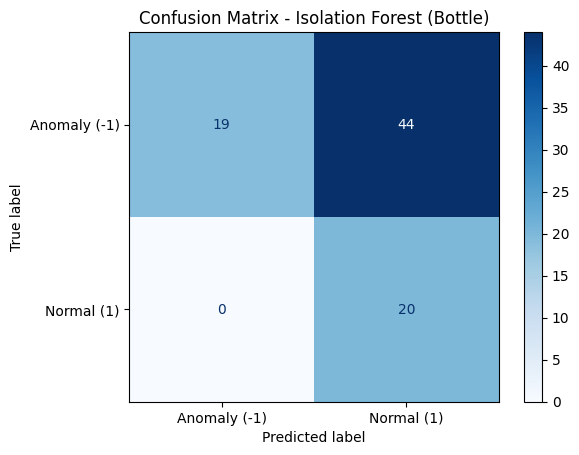

In [8]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(f"--- Model Performance for '{CATEGORY.capitalize()}': Classification Report ---")


target_names = ['Anomaly (-1)', 'Normal (1)']
print(classification_report(y_true, y_pred, target_names=target_names))

print(f"\n--- Model Performance for '{CATEGORY.capitalize()}': Confusion Matrix ---")


ConfusionMatrixDisplay.from_predictions(y_true,
                                        y_pred,
                                        display_labels=target_names,
                                        cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix - Isolation Forest ({CATEGORY.capitalize()})")
plt.show()


--- Model Performance for 'Bottle': AUROC Score ---
Calculated AUROC Score for 'Bottle': 0.6937


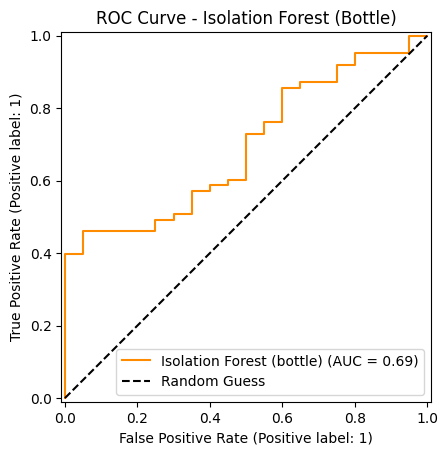

In [9]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

print(f"\n--- Model Performance for '{CATEGORY.capitalize()}': AUROC Score ---")


anomaly_scores = model.decision_function(X_test)


y_scores = -anomaly_scores


y_true_for_roc = [0 if x == 1 else 1 for x in y_true]


auroc_score = roc_auc_score(y_true_for_roc, y_scores)
print(f"Calculated AUROC Score for '{CATEGORY.capitalize()}': {auroc_score:.4f}")


RocCurveDisplay.from_predictions(y_true_for_roc, y_scores, name=f"Isolation Forest ({CATEGORY})", color="darkorange")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess") # Random guess line
plt.title(f"ROC Curve - Isolation Forest ({CATEGORY.capitalize()})")
plt.legend()
plt.show()

In [10]:

end_time = time.time()
elapsed_time = end_time - start_time

print(f"The process took {elapsed_time:.2f} seconds.")
print(f"({elapsed_time / 60:.2f} minutes)")

The process took 62.72 seconds.
(1.05 minutes)
